# EEG-CogState — Sprint 2 : Prétraitement du signal

**Objectif du Sprint 2** (cahier des charges) : transformer le signal brut en signal propre et segmenté.

Trois opérations, dans l'ordre :
1. **Filtre passe-bande (1–45 Hz)** — enlève les dérives lentes et le bruit haute fréquence
2. **Filtre notch (50 Hz)** — supprime le bruit du courant secteur
3. **Segmentation en epochs** — découpe le signal en fenêtres de 2 s

Tout est implémenté dans `src/preprocessing.py`. Ce notebook montre l'effet de chaque étape.

## 1. Imports et configuration

In [25]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src import config, io_eeg, preprocessing, viz

print("Filtre passe-bande :", config.BANDPASS_LOW, "-", config.BANDPASS_HIGH, "Hz")
print("Filtre notch       :", config.NOTCH_FREQ, "Hz")
print("Duree d'un epoch   :", config.EPOCH_SECONDS, "s")
print("Recouvrement       :", int(config.EPOCH_OVERLAP * 100), "%")

Filtre passe-bande : 1.0 - 45.0 Hz
Filtre notch       : 50.0 Hz
Duree d'un epoch   : 2.0 s
Recouvrement       : 50 %


## 2. On charge un enregistrement

On prend un fichier en condition `hi` (concentration) pour observer le pic bêta.

In [26]:
catalogue = io_eeg.list_recordings()

# On cherche un fichier 'hi' ; sinon on prend le premier disponible
hi = catalogue[catalogue["suffix"] == "hi"]
sample_path = (hi.iloc[0] if not hi.empty else catalogue.iloc[0])["path"]

df = io_eeg.load_recording(sample_path)
meta = io_eeg.parse_filename(sample_path)
print("Fichier :", meta["filename"], "| etat :", meta["label"])
print("Forme du signal brut :", df.shape)

Fichier : sub11_hi.txt | etat : concentration
Forme du signal brut : (19200, 14)


## 3. Nettoyage : avant / après

On applique la chaîne complète (`clean_signal`) et on compare le signal et son spectre.

**Ce qu'il faut observer dans le spectre :**
- le pic à **50 Hz** (bruit secteur) doit **disparaître** après nettoyage
- les fréquences au-delà de 45 Hz sont coupées
- le signal utile (ici le pic bêta vers 20 Hz) est **préservé**

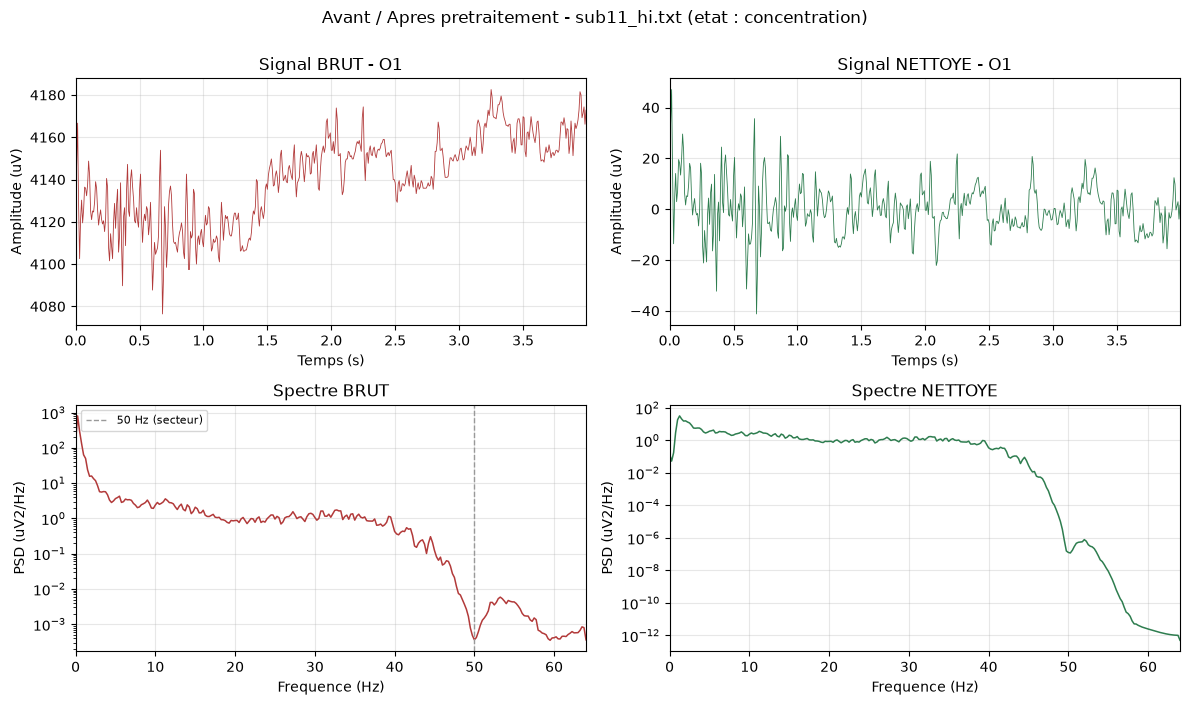

In [27]:
fig = viz.plot_before_after(sample_path, channel="O1", n_seconds=4)
plt.show()

## 4. Vérification chiffrée du filtrage

On mesure la puissance à 50 Hz avant et après, pour confirmer objectivement
que le bruit secteur est supprimé et que le signal utile reste intact.

In [28]:
from scipy.signal import welch

raw = df["O1"].values
clean = preprocessing.clean_signal(df)[:, config.CHANNEL_NAMES.index("O1")]

f, p_raw = welch(raw, fs=config.SAMPLING_RATE, nperseg=512)
_, p_clean = welch(clean, fs=config.SAMPLING_RATE, nperseg=512)

def band_power(freqs, psd, lo, hi):
    m = (freqs >= lo) & (freqs <= hi)
    return psd[m].max()

print(f"Puissance ~50 Hz  AVANT : {band_power(f, p_raw, 48, 52):10.2f}")
print(f"Puissance ~50 Hz  APRES : {band_power(f, p_clean, 48, 52):10.4f}")
print(f"Puissance ~20 Hz  AVANT : {band_power(f, p_raw, 19, 21):10.2f}  (signal utile)")
print(f"Puissance ~20 Hz  APRES : {band_power(f, p_clean, 19, 21):10.2f}  (doit rester ~identique)")

Puissance ~50 Hz  AVANT :       0.01
Puissance ~50 Hz  APRES :     0.0002
Puissance ~20 Hz  AVANT :       1.06  (signal utile)
Puissance ~20 Hz  APRES :       1.06  (doit rester ~identique)


## 5. Segmentation en epochs

On découpe le signal nettoyé en fenêtres de 2 secondes (avec 50 % de recouvrement).
C'est l'étape qui transforme **un** enregistrement en **dizaines** d'exemples.

In [29]:
cleaned = preprocessing.clean_signal(df)
epochs = preprocessing.segment_epochs(cleaned)

print("Forme du signal nettoye :", cleaned.shape, "(echantillons x canaux)")
print("Forme des epochs        :", epochs.shape, "(epochs x echantillons x canaux)")
print(f"\n-> {epochs.shape[0]} epochs de {epochs.shape[1]} echantillons "
      f"({config.EPOCH_SECONDS}s) chacun")

Forme du signal nettoye : (19200, 14) (echantillons x canaux)
Forme des epochs        : (149, 256, 14) (epochs x echantillons x canaux)

-> 149 epochs de 256 echantillons (2.0s) chacun


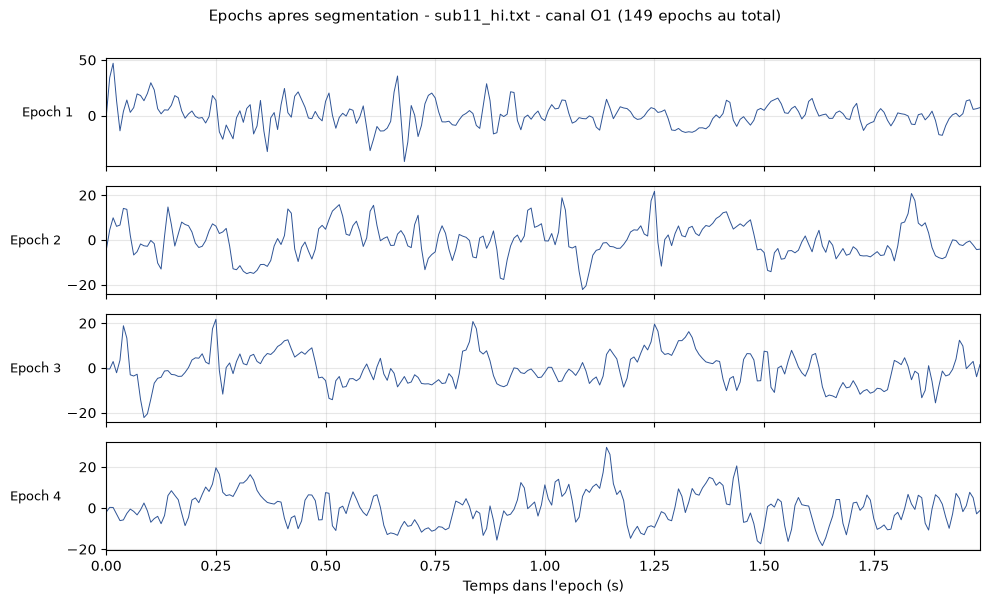

In [30]:
fig = viz.plot_epochs_overview(sample_path, channel="O1", n_show=4)
plt.show()

## 6. Pipeline complet sur un fichier

La fonction `preprocess_file` enchaîne tout (chargement + nettoyage + epoching)
et renvoie les epochs prêts, avec l'étiquette et le sujet. C'est ce qu'on
appellera au **Sprint 3** pour extraire les features.

In [31]:
result = preprocessing.preprocess_file(sample_path)

print("Resultat du pipeline :")
print("  sujet    :", result["subject"])
print("  etat     :", result["label"])
print("  n_epochs :", result["n_epochs"])
print("  forme    :", result["epochs"].shape)

Resultat du pipeline :
  sujet    : 11
  etat     : concentration
  n_epochs : 149
  forme    : (149, 256, 14)


In [32]:
# Aperçu : combien d'epochs au total sur tous les fichiers disponibles ?
total = 0
print("Epochs produits par fichier :\n")
for _, row in catalogue.iterrows():
    res = preprocessing.preprocess_file(row["path"])
    total += res["n_epochs"]
    print(f"  {row['filename']:14s} [{res['label']:14s}] -> {res['n_epochs']} epochs")
print(f"\nTOTAL : {total} epochs disponibles pour l'entrainement (Sprint 4)")

Epochs produits par fichier :

  sub10_lo.txt   [relaxation    ] -> 149 epochs
  sub10_lo.txt   [relaxation    ] -> 149 epochs
  sub11_hi.txt   [concentration ] -> 149 epochs
  sub11_hi.txt   [concentration ] -> 149 epochs
  sub11_lo.txt   [relaxation    ] -> 149 epochs
  sub11_lo.txt   [relaxation    ] -> 149 epochs
  sub12_hi.txt   [concentration ] -> 149 epochs
  sub12_hi.txt   [concentration ] -> 149 epochs

TOTAL : 1192 epochs disponibles pour l'entrainement (Sprint 4)


## ✅ Bilan du Sprint 2

À ce stade, on sait :
- filtrer le signal (passe-bande + notch) et **vérifier** que le bruit est supprimé ;
- découper le signal en epochs exploitables ;
- enchaîner le tout avec `preprocess_file`.

Le signal est maintenant **propre et segmenté**. Chaque fichier produit des dizaines d'epochs.

**Prochaine étape (Sprint 3)** : extraire un vecteur de features de chaque epoch — puissances des bandes (delta→gamma), ratios, et indicateurs statistiques — pour construire le tableau qui nourrira le modèle.